In [1]:
# Import custom scripts
from scripts import analysis, datahandler, visuals, simulation
from importlib import reload

for module in (analysis, datahandler, visuals, simulation):
    reload(module)

# Import python essentials
import os
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

>> Loaded .../S-order_2dcurved_r-40.0um.csv | cols ['S'] | shape (4357,)
>> Loaded .../S-order_2dcurved_r-40.0um.csv | cols ['S'] | shape (4314,)
>> Loaded .../S-order_2dcurved_r-40.0um.csv | cols ['S'] | shape (5543,)
>> Loaded .../S-order_2dcurved_r-40.0um.csv | cols ['S'] | shape (5633,)
>> Loaded .../S-order_2dcurved_r-40.0um.csv | cols ['S'] | shape (2371,)
>> Loaded .../S-order_2dcurved_r-40.0um.csv | cols ['S'] | shape (2420,)


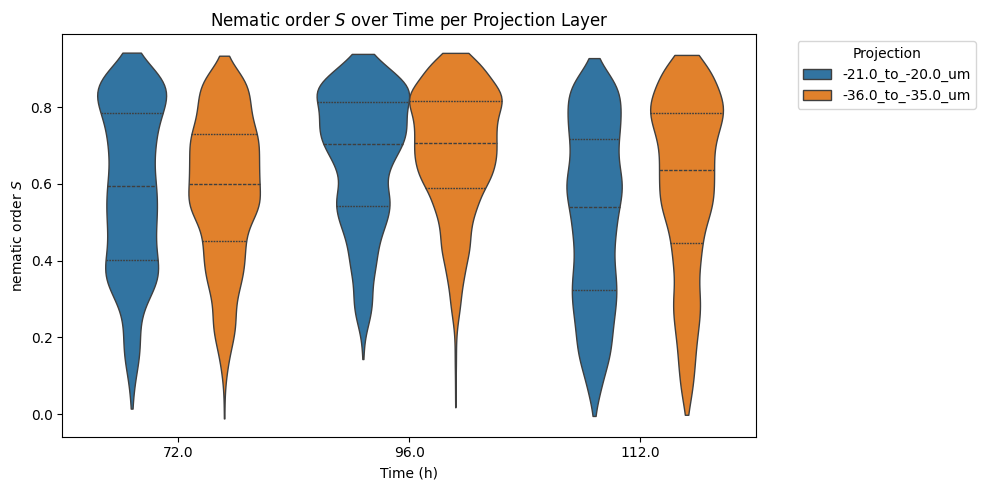

In [37]:
root = "/Users/andreadi/Desktop/test"

data = []
for tp in os.listdir(root):
    data_dir = os.path.join(root, tp, "data")
    if not os.path.isdir(data_dir):
        continue
    for proj in os.listdir(data_dir):
        folder = os.path.join(data_dir, proj)
        if not os.path.isdir(folder):
            continue
        s_val = datahandler.load_array("S-order_2dcurved_r-40.0um", folderpath=folder)
        data.append({
            "Time": int(tp.split("h")[0]),
            "Projection": proj.split("proj_")[-1],
            "S": s_val
        })

# Convert to dataframe
df = pd.DataFrame(data)
df = df.explode("S")
df["S"] = df["S"].astype(float)

# Sort times numerically
df["Time"] = df["Time"].astype(float)
df = df.sort_values("Time")

# Violin plot grouped by projection layer
plt.figure(figsize=(10, 5))
sns.violinplot(
    data=df,
    x="Time",
    y="S",
    hue="Projection",
    inner="quartile",
    cut=0,
    linewidth=1
)
plt.title("Nematic order $S$ over Time per Projection Layer")
plt.xlabel("Time (h)")
plt.ylabel("nematic order $S$")
plt.legend(title="Projection", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(root, "S-order over Time per Projection Layer"), dpi=300)
plt.show()

# TAC figures

In [ ]:
# =================================================================
local_nneigh = 7
crop_max_ar = 5  # Max for colorbar !
local_S_weighted_max = 3.0  # Max for colorbar !


# =================================================================

def quick_load_seg(path, xy_pixel_scale):
    seg_ellips_results = datahandler.load_array(name=f"{0 + 1:04d}_seg-ellipses", folderpath=path,
                                                return_df=True)
    # seg_ellips_results = datahandler.load_array(name=f"{img_name}_z{z_sel + 1}_cp_masks_ellipses",
    #                                             folderpath=path, return_df=True)
    # os.path.join(os.path.dirname(img_path),"z_slice_segmentation", img_name)
    seg_ellips_results["Ellipse.Orientation"] *= -1
    seg_ellips_results["Ellipse.Radius1"] *= xy_pixel_scale
    seg_ellips_results["Ellipse.Radius2"] *= xy_pixel_scale
    seg_ellips_results["aspect_ratio"] = seg_ellips_results["Ellipse.Radius1"] / seg_ellips_results[
        "Ellipse.Radius2"]
    seg_ellips_results["shape_scalar"] = seg_ellips_results["aspect_ratio"] - 1
    seg_ellips_results = seg_ellips_results[seg_ellips_results["aspect_ratio"] < crop_max_ar]
    return seg_ellips_results


img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/segmentation_examples/72.tif"
print(f"Selected image path: {img_path}")
img_load = analysis.load_img_virtual(path=img_path, t_sel_idx=0, c_sel_idx=0, reduce_xy=1,
                                     reduce_z=1, norm_vals=False, custom_scaling=None, custom_unit="um")
img_raw, img_dim, img_scale, img_unit = img_load
resdata_dir, resfig_dir = datahandler.create_resdirs(img_path)
resfig_dir_2dsliced = os.path.join(resfig_dir, "2d-sliced_analysis")
resdata_dir_2dsliced = os.path.join(resdata_dir, "2d-sliced_analysis")
datahandler.create_dir(resfig_dir_2dsliced)
datahandler.create_dir(resdata_dir_2dsliced)
seg_ellips_results_72h = quick_load_seg(path=resdata_dir_2dsliced, xy_pixel_scale=np.mean(img_scale[1:]))
print(seg_ellips_results_72h["Ellipse.Radius1"].max())
medial_curve_72h = datahandler.load_array("curve", folderpath=resdata_dir_2dsliced)
seg_directors_2d_72h = np.column_stack((seg_ellips_results_72h["Ellipse.Center.X"],
                                        seg_ellips_results_72h["Ellipse.Center.Y"],
                                        np.cos(np.radians(seg_ellips_results_72h["Ellipse.Orientation"])),
                                        np.sin(np.radians(seg_ellips_results_72h["Ellipse.Orientation"]))))
seg_directors_2d_72h[:, :2] *= img_scale[1:]
s_parallel_72h, s_orthogonal_72h = analysis.proj2curve(seg_directors_2d_72h[:, :2], medial_curve_72h)

local_idxs_72h = analysis.coord_search_neighbours(seg_directors_2d_72h[:, :2], k=local_nneigh)
S_2d_seg_local_72h, n_2d_seg_local_72h = analysis.avg_2d_nem_tens(seg_directors_2d_72h, weights=None,
                                                                  neigh_idxs=local_idxs_72h)
S_2d_seg_local_weighted_72h, n_2d_seg_local_72h = analysis.avg_2d_nem_tens(seg_directors_2d_72h, local_idxs_72h,
                                                                           weights=np.array(
                                                                               seg_ellips_results_72h["shape_scalar"]))

img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/segmentation_examples/96.tif"
print(f"Selected image path: {img_path}")
img_load = analysis.load_img_virtual(path=img_path, t_sel_idx=0, c_sel_idx=0, reduce_xy=1,
                                     reduce_z=1, norm_vals=False, custom_scaling=None, custom_unit="um")
img_raw, img_dim, img_scale, img_unit = img_load
resdata_dir, resfig_dir = datahandler.create_resdirs(img_path)
resfig_dir_2dsliced = os.path.join(resfig_dir, "2d-sliced_analysis")
resdata_dir_2dsliced = os.path.join(resdata_dir, "2d-sliced_analysis")
datahandler.create_dir(resfig_dir_2dsliced)
datahandler.create_dir(resdata_dir_2dsliced)
seg_ellips_results_96h = quick_load_seg(path=resdata_dir_2dsliced, xy_pixel_scale=np.mean(img_scale[1:]))
print(seg_ellips_results_96h["Ellipse.Radius1"].max())
medial_curve_96h = datahandler.load_array("curve", folderpath=resdata_dir_2dsliced)
seg_directors_2d_96h = np.column_stack((seg_ellips_results_96h["Ellipse.Center.X"],
                                        seg_ellips_results_96h["Ellipse.Center.Y"],
                                        np.cos(np.radians(seg_ellips_results_96h["Ellipse.Orientation"])),
                                        np.sin(np.radians(seg_ellips_results_96h["Ellipse.Orientation"]))))
seg_directors_2d_96h[:, :2] *= img_scale[1:]
s_parallel_96h, s_orthogonal_96h = analysis.proj2curve(seg_directors_2d_96h[:, :2], medial_curve_96h)
local_idxs_96h = analysis.coord_search_neighbours(seg_directors_2d_96h[:, :2], k=local_nneigh)
S_2d_seg_local_96h, n_2d_seg_local_96h = analysis.avg_2d_nem_tens(seg_directors_2d_96h, weights=None,
                                                                  neigh_idxs=local_idxs_96h)
S_2d_seg_local_weighted_96h, n_2d_seg_local_96h = analysis.avg_2d_nem_tens(seg_directors_2d_96h, local_idxs_96h,
                                                                           weights=np.array(
                                                                               seg_ellips_results_96h["shape_scalar"]))

img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/segmentation_examples/120.tif"
print(f"Selected image path: {img_path}")
img_load = analysis.load_img_virtual(path=img_path, t_sel_idx=0, c_sel_idx=0, reduce_xy=1,
                                     reduce_z=1, norm_vals=False, custom_scaling=None, custom_unit="um")
img_raw, img_dim, img_scale, img_unit = img_load
resdata_dir, resfig_dir = datahandler.create_resdirs(img_path)
resfig_dir_2dsliced = os.path.join(resfig_dir, "2d-sliced_analysis")
resdata_dir_2dsliced = os.path.join(resdata_dir, "2d-sliced_analysis")
datahandler.create_dir(resfig_dir_2dsliced)
datahandler.create_dir(resdata_dir_2dsliced)
seg_ellips_results_120h = quick_load_seg(path=resdata_dir_2dsliced, xy_pixel_scale=np.mean(img_scale[1:]))
medial_curve_120h = datahandler.load_array("curve", folderpath=resdata_dir_2dsliced)
seg_directors_2d_120h = np.column_stack((seg_ellips_results_120h["Ellipse.Center.X"],
                                         seg_ellips_results_120h["Ellipse.Center.Y"],
                                         np.cos(np.radians(seg_ellips_results_120h["Ellipse.Orientation"])),
                                         np.sin(np.radians(seg_ellips_results_120h["Ellipse.Orientation"]))))
seg_directors_2d_120h[:, :2] *= img_scale[1:]
s_parallel_120h, s_orthogonal_120h = analysis.proj2curve(seg_directors_2d_120h[:, :2], medial_curve_120h)
local_idxs_120h = analysis.coord_search_neighbours(seg_directors_2d_120h[:, :2], k=local_nneigh)
S_2d_seg_local_120h, n_2d_seg_local_120h = analysis.avg_2d_nem_tens(seg_directors_2d_120h, weights=None,
                                                                    neigh_idxs=local_idxs_120h)
S_2d_seg_local_weighted_120h, n_2d_seg_local_120h = analysis.avg_2d_nem_tens(seg_directors_2d_120h, local_idxs_120h,
                                                                             weights=np.array(
                                                                                 seg_ellips_results_120h[
                                                                                     "shape_scalar"]))

In [ ]:
figpath = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/segmentation_examples/!COMPARISON"

visuals.plot_violinplot_comparative(
    sequence_data=[[seg_ellips_results_72h["Ellipse.Radius1"], seg_ellips_results_72h["Ellipse.Radius2"]],
                   [seg_ellips_results_96h["Ellipse.Radius1"], seg_ellips_results_96h["Ellipse.Radius2"]],
                   [seg_ellips_results_120h["Ellipse.Radius1"], seg_ellips_results_120h["Ellipse.Radius2"]]],
    sequence_labels=["72h", "96h", "120h"], group_labels=["Long Axis", "Short Axis"],
    title=f"Ellipse Axes ({img_unit})", savefig=os.path.join(figpath, "ellipse-axes.pdf"))

visuals.plot_violinplot_comparative(
    sequence_data=[[S_2d_seg_local_72h, S_2d_seg_local_weighted_72h],
                   [S_2d_seg_local_96h, S_2d_seg_local_weighted_96h],
                   [S_2d_seg_local_120h, S_2d_seg_local_weighted_120h]],
    sequence_labels=["72h", "96h", "120h"], group_labels=["Normalised", "Weighted by AR-1"],
    title=f"Local Nematic Order w.r.t. {local_nneigh - 1} Neighbours",
    savefig=os.path.join(figpath, f"local-nematic-order-k={local_nneigh}.pdf"))

# visuals.plot_violinplot(sequence_data=[seg_ellips_results_72h["aspect_ratio"], seg_ellips_results_96h["aspect_ratio"],
#                                        seg_ellips_results_120h["aspect_ratio"]], sequence_labels=["72h", "96h", "120h"],
#                         title=f"Aspect Ratio ({img_unit})", savefig=os.path.join(figpath, "ellipse-aspect-ratios.pdf"), figsize=(5,5))
#
# sequence_labels = ["72h", "96h", "120h"]
#
# plt.figure(figsize=(6, 5))
# # Plot the lines with markers, colors, and linewidths
# plt.plot([s_parallel_72h.max(), s_parallel_96h.max(), s_parallel_120h.max()],
#          marker='s', linestyle='-', color='tab:blue', linewidth=2, markersize=8,
#          label=f"Parallel to elongation")
#
# plt.plot([s_orthogonal_72h.max(), s_orthogonal_96h.max(), s_orthogonal_120h.max()],
#          marker='o', linestyle='-', color='tab:orange', linewidth=2, markersize=8,
#          label=f"Orthogonal to elongation")
#
# # X-axis labels
# plt.xticks(range(len(sequence_labels)), sequence_labels)
#
# # Labels and title
# plt.xlabel("Time")
# plt.ylabel(f"Elongation ({img_unit})")
# plt.title(f"Tissue Elongation over Time ({img_unit})")
#
# # Grid and legend
# plt.grid(alpha=0.3)
# plt.legend()
# plt.savefig(os.path.join(figpath, "tissue-elongation.pdf"))
# plt.tight_layout()
# plt.show()


# Anàlisi del turbo run

In [2]:
# =================================================================
local_nneigh = 7  # Always number of neighbours + 1 !
crop_max_ar = 5  # Max for colorbar !
local_S_weighted_max = 3.0  # Max for colorbar !


# =================================================================
def extract_all(chosen_time_point, chosen_size, chosen_gastruloid):
    img_path = f"/Volumes/roux/AurelienRouxLab/Oriol/Experiments 2 photon with filter/Gastruloids size exp/EXP4_FILTER/{chosen_time_point}/{chosen_size}/{chosen_gastruloid}.tif"
    print(f"Selected image path: {img_path}")
    if not os.path.exists(img_path):
        print(f"Image path does not exist: {img_path} !")
        return None
    # img_load = analysis.load_img_virtual(path=img_path, t_sel_idx=0, c_sel_idx=0, reduce_xy=1,
    #                                      reduce_z=1, norm_vals=False, custom_scaling=None, custom_unit="um")
    # if img_load is None:
    #     print(f"Could not load image: {img_path}!")
    #     return None
    # img_raw, img_dim, img_scale, img_unit = img_load
    img_scale = analysis.load_img_scaling(img_path)
    img_name = os.path.basename(img_path).split(".tif")[0]
    resdata_dir, resfig_dir = datahandler.create_resdirs(img_path)
    resfig_dir_2dsliced = os.path.join(resfig_dir, "2d-sliced_analysis")
    if not os.path.exists(resfig_dir_2dsliced):
        datahandler.create_dir(resfig_dir_2dsliced)
    resdata_dir_2dsliced = os.path.join(resdata_dir, "2d-sliced_analysis")
    if not os.path.exists(resdata_dir_2dsliced):
        datahandler.create_dir(resdata_dir_2dsliced)

    seg_path = os.path.join(os.path.dirname(img_path), "z_slice_segmentation", img_name)
    if not os.path.exists(seg_path):
        print(f"No segmentation for {img_name} !")
        return None
    seg_items = os.listdir(seg_path)
    seg_masks = np.array([f for f in seg_items if f.endswith(".png")])
    seg_z_vals = np.array([
        int(m.group(1)) for f in seg_masks if (m := re.search(r"_z(\d+)_", f))
    ])
    valid_z_all = []
    aspect_ratio_all = []
    S_local_normalised_all = []
    S_local_weighted_all = []
    S_avg_normalised_all = []
    S_avg_weighted_all = []
    for chosen_zslice in seg_z_vals:
        try:
            seg_ellips_results = datahandler.load_array(name=f"{img_name}_z{chosen_zslice}_cp_masks_ellipses",
                                                        folderpath=seg_path, return_df=True, debug=False)
        except:
            print(f"[!!] Fatal error when loading ellipses for z={chosen_zslice}")
            continue
        if seg_ellips_results is None:
            print(f"No ellipses found for z={chosen_zslice}")
            continue
        seg_ellips_results["Ellipse.Orientation"] *= -1
        seg_ellips_results["Ellipse.Radius1"] *= np.mean(img_scale[1:])
        seg_ellips_results["Ellipse.Radius2"] *= np.mean(img_scale[1:])
        seg_ellips_results["aspect_ratio"] = seg_ellips_results["Ellipse.Radius1"] / seg_ellips_results[
            "Ellipse.Radius2"]
        seg_ellips_results["shape_scalar"] = seg_ellips_results["aspect_ratio"] - 1
        seg_ellips_results = seg_ellips_results[seg_ellips_results["aspect_ratio"] < crop_max_ar]
        if len(seg_ellips_results) >= local_nneigh:
            seg_directors_2d = np.column_stack((seg_ellips_results["Ellipse.Center.X"],
                                                seg_ellips_results["Ellipse.Center.Y"],
                                                np.cos(np.radians(seg_ellips_results["Ellipse.Orientation"])),
                                                np.sin(np.radians(seg_ellips_results["Ellipse.Orientation"]))))
            seg_directors_2d[:, :2] *= img_scale[1:]
            # medial_curve = datahandler.load_array("curve", folderpath=resdata_dir_2dsliced)
            # s_parallel, s_orthogonal = analysis.proj2curve(seg_directors_2d[:, :2], medial_curve)
            local_idxs = analysis.coord_search_neighbours(seg_directors_2d[:, :2], k=local_nneigh)
            S_2d_seg_local, n_2d_seg_local = analysis.avg_2d_nem_tens(seg_directors_2d, weights=None,
                                                                      neigh_idxs=local_idxs)
            S_2d_seg_local_weighted, n_2d_seg_local = analysis.avg_2d_nem_tens(seg_directors_2d, local_idxs,
                                                                               weights=np.array(seg_ellips_results[
                                                                                                    "shape_scalar"]))

            S_2d_seg_slice, _ = analysis.avg_2d_nem_tens(seg_directors_2d,
                                                         neigh_idxs=[np.arange(len(seg_directors_2d))], weights=None)
            S_2d_seg_slice_weighted, _ = analysis.avg_2d_nem_tens(seg_directors_2d,
                                                                  neigh_idxs=[np.arange(len(seg_directors_2d))],
                                                                  weights=np.array(seg_ellips_results["shape_scalar"]))
            valid_z_all.append(chosen_zslice)
            aspect_ratio_all.append(seg_ellips_results["aspect_ratio"].to_numpy())
            S_local_normalised_all.append(S_2d_seg_local)
            S_local_weighted_all.append(S_2d_seg_local_weighted)
            S_avg_normalised_all.append(S_2d_seg_slice[0])
            S_avg_weighted_all.append(S_2d_seg_slice_weighted[0])
    return img_path, img_scale, valid_z_all, aspect_ratio_all, S_local_normalised_all, S_local_weighted_all, S_avg_normalised_all, S_avg_weighted_all

In [3]:
root_dir = "/Volumes/roux/AurelienRouxLab/Oriol/Experiments 2 photon with filter/Gastruloids size exp/EXP4_FILTER/"
time_points = ["72", "96", "104", "112", "120"]
seeding_sizes = ["200", "300"]
all_data = {}
for tp in time_points:
    print(f">> Processing time: {tp}")
    all_data[tp] = {}
    for size in seeding_sizes:
        print(f">>-->> Processing seeding size: {size}")
        folder_path = os.path.join(root_dir, tp, size)
        if not os.path.exists(folder_path):
            continue
        file_names = os.listdir(folder_path)
        gastruloid_names = [f.split(".tif")[0] for f in file_names if f.endswith(".tif")]
        all_data[tp][size] = {}
        for gas_name in gastruloid_names:
            analysis_packet = extract_all(chosen_time_point=tp, chosen_size=size, chosen_gastruloid=gas_name)
            if analysis_packet is not None:
                all_data[tp][size][gas_name] = analysis_packet

>> Processing time: 72
>>-->> Processing seeding size: 200
Selected image path: /Volumes/roux/AurelienRouxLab/Oriol/Experiments 2 photon with filter/Gastruloids size exp/EXP4_FILTER/72/200/Gas4.tif
>> Loading /Volumes/roux/AurelienRouxLab/Oriol/Experiments 2 photon with filter/Gastruloids size exp/EXP4_FILTER/72/200/Gas4.tif...
Found xscale = 0.12036562261525609, yscale = 0.12036562261525609 !
Found zscale = 2.5004 !
Selected image path: /Volumes/roux/AurelienRouxLab/Oriol/Experiments 2 photon with filter/Gastruloids size exp/EXP4_FILTER/72/200/Gas3.tif
>> Loading /Volumes/roux/AurelienRouxLab/Oriol/Experiments 2 photon with filter/Gastruloids size exp/EXP4_FILTER/72/200/Gas3.tif...
Found xscale = 0.12036562261525609, yscale = 0.12036562261525609 !
Found zscale = 2.5004 !
Selected image path: /Volumes/roux/AurelienRouxLab/Oriol/Experiments 2 photon with filter/Gastruloids size exp/EXP4_FILTER/72/200/Gas2.tif
>> Loading /Volumes/roux/AurelienRouxLab/Oriol/Experiments 2 photon with filte

# Dataset Creation

In [4]:
# ---- Local (cell-level) ----
records = []

for tp, sizes in all_data.items():
    for size, gastruloids in sizes.items():
        for gas_name, packet in gastruloids.items():
            _, _, valid_z, aspect_ratio_all, S_local_norm, S_local_weighted, S_avg_norm, S_avg_weighted = packet
            for z, aspect_array, S_arr, S_norm_arr in zip(valid_z, aspect_ratio_all, S_local_weighted, S_local_norm):
                for S_val, S_norm_val, ar in zip(S_arr, S_norm_arr, aspect_array):
                    records.append({
                        "time_point": tp,
                        "size": size,
                        "gastruloid": gas_name,
                        "slice_z": z,
                        "aspect_ratio": ar,
                        "S_value": S_val,
                        "S_value_norm": S_norm_val
                    })

local_df = pd.DataFrame.from_records(records)

# ---- Slice-level (average) ----
avg_records = []

for tp, sizes in all_data.items():
    for size, gastruloids in sizes.items():
        for gas_name, packet in gastruloids.items():
            _, _, valid_z, aspect_ratio_all, S_local_norm, S_local_weighted, S_avg_norm, S_avg_weighted = packet
            for z, aspect_array, S_val, S_norm_val in zip(valid_z, aspect_ratio_all, S_avg_weighted, S_avg_norm):
                aspect_ratio = np.mean(aspect_array)  # average per slice for avg_df
                avg_records.append({
                    "time_point": tp,
                    "size": size,
                    "gastruloid": gas_name,
                    "slice_z": z,
                    "aspect_ratio": aspect_ratio,
                    "S_avg": S_val,
                    "S_avg_norm": S_norm_val
                })

avg_df = pd.DataFrame.from_records(avg_records)

In [5]:
num_gastruloids = avg_df['gastruloid'].nunique()
num_sizes = avg_df['size'].nunique()
num_time_points = avg_df['time_point'].nunique()

print(f"Gastruloids: {num_gastruloids}")
print(f"Seeding sizes: {num_sizes}")
print(f"Time points: {num_time_points}")
print("Gastruloids per size:")
print(avg_df.groupby('size')['gastruloid'].nunique())

print("\nGastruloids per time point:")
print(avg_df.groupby('time_point')['gastruloid'].nunique())

print("\nGastruloids per time point and size:")
print(avg_df.groupby(['time_point', 'size'])['gastruloid'].nunique())

Gastruloids: 14
Seeding sizes: 2
Time points: 5
Gastruloids per size:
size
200    11
300    13
Name: gastruloid, dtype: int64

Gastruloids per time point:
time_point
104    10
112     9
120    13
72      4
96      9
Name: gastruloid, dtype: int64

Gastruloids per time point and size:
time_point  size
104         200     10
            300      3
112         200      5
            300      6
120         200      5
            300     10
72          200      3
            300      4
96          200      6
            300      8
Name: gastruloid, dtype: int64


# Save/Load Dataset

In [6]:
local_df.to_feather("/Users/andreadi/Desktop/local_df_backup.feather")
avg_df.to_feather("/Users/andreadi/Desktop/avg_df_backup.feather")

print("Feather backups saved safely!")

Feather backups saved safely!


In [2]:
local_df = pd.read_feather("/Users/andreadi/Desktop/local_df_backup.feather")
print(f"Loaded local df with columns {list(local_df.columns)}")
avg_df = pd.read_feather("/Users/andreadi/Desktop/avg_df_backup.feather")
print(f"Loaded average df with columns {list(avg_df.columns)}")

Loaded local df with columns ['time_point', 'size', 'gastruloid', 'slice_z', 'aspect_ratio', 'S_value', 'S_value_norm']
Loaded average df with columns ['time_point', 'size', 'gastruloid', 'slice_z', 'aspect_ratio', 'S_avg', 'S_avg_norm']


# Plotting

In [26]:
comp_fig_dir = '/Volumes/roux/AurelienRouxLab/Oriol/Experiments 2 photon with filter/Gastruloids size exp/EXP4_FILTER/!COMPARATIVE'
comp_fig_dpi = 200
comp_fig_type = "png"

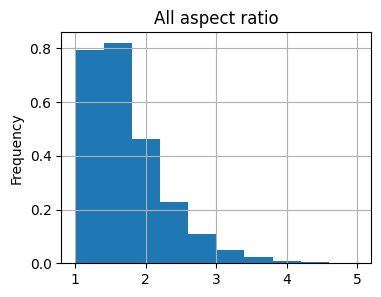

In [56]:
visuals.plot_hist(local_df["aspect_ratio"], title="All aspect ratio")

## Overview of Dataset Statistics

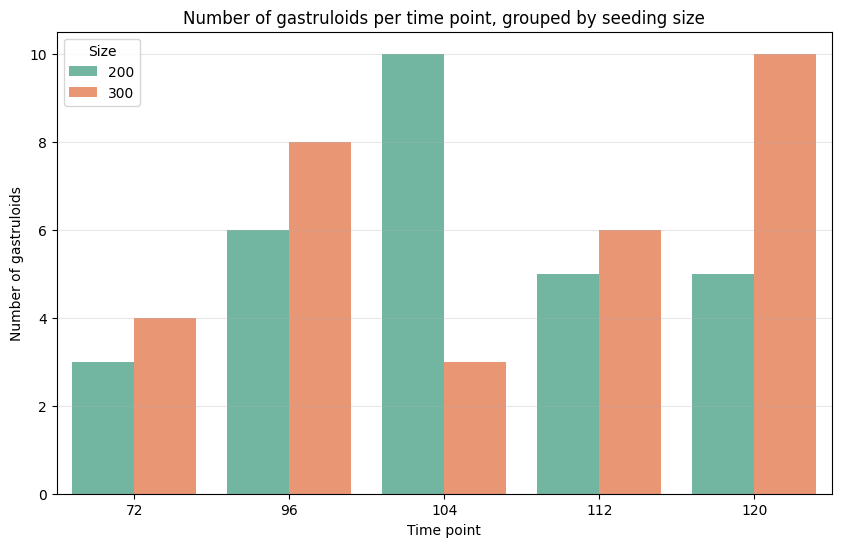

In [27]:
# ---- Step 1: count gastruloids per time point and size ----
gastruloid_counts = (
    avg_df.groupby(['time_point', 'size'])['gastruloid']
    .nunique()
    .reset_index()  # reset_index first
)

# Rename the new column
gastruloid_counts.rename(columns={'gastruloid': 'n_gastruloids'}, inplace=True)

# Ensure time points are ordered numerically
gastruloid_counts['time_point'] = pd.Categorical(
    gastruloid_counts['time_point'],
    categories=sorted(gastruloid_counts['time_point'].unique(), key=int),
    ordered=True
)

# ---- Step 2: plot ----
plt.figure(figsize=(10, 6))
sns.barplot(
    data=gastruloid_counts,
    x='time_point',
    y='n_gastruloids',
    hue='size',
    palette='Set2'
)

plt.xlabel("Time point")
plt.ylabel("Number of gastruloids")
plt.title("Number of gastruloids per time point, grouped by seeding size")
plt.grid(alpha=0.3, axis='y')
plt.legend(title='Size')
plt.savefig(os.path.join(comp_fig_dir, f'overall-count_statistics.{comp_fig_type}'), dpi=comp_fig_dpi)
plt.show()

/var/folders/tr/c3y2bbmj497_wxvc_66mzyqr0000gn/T/ipykernel_75005/2460237405.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cells_per_slice.groupby(['time_point', 'size', 'gastruloid'])


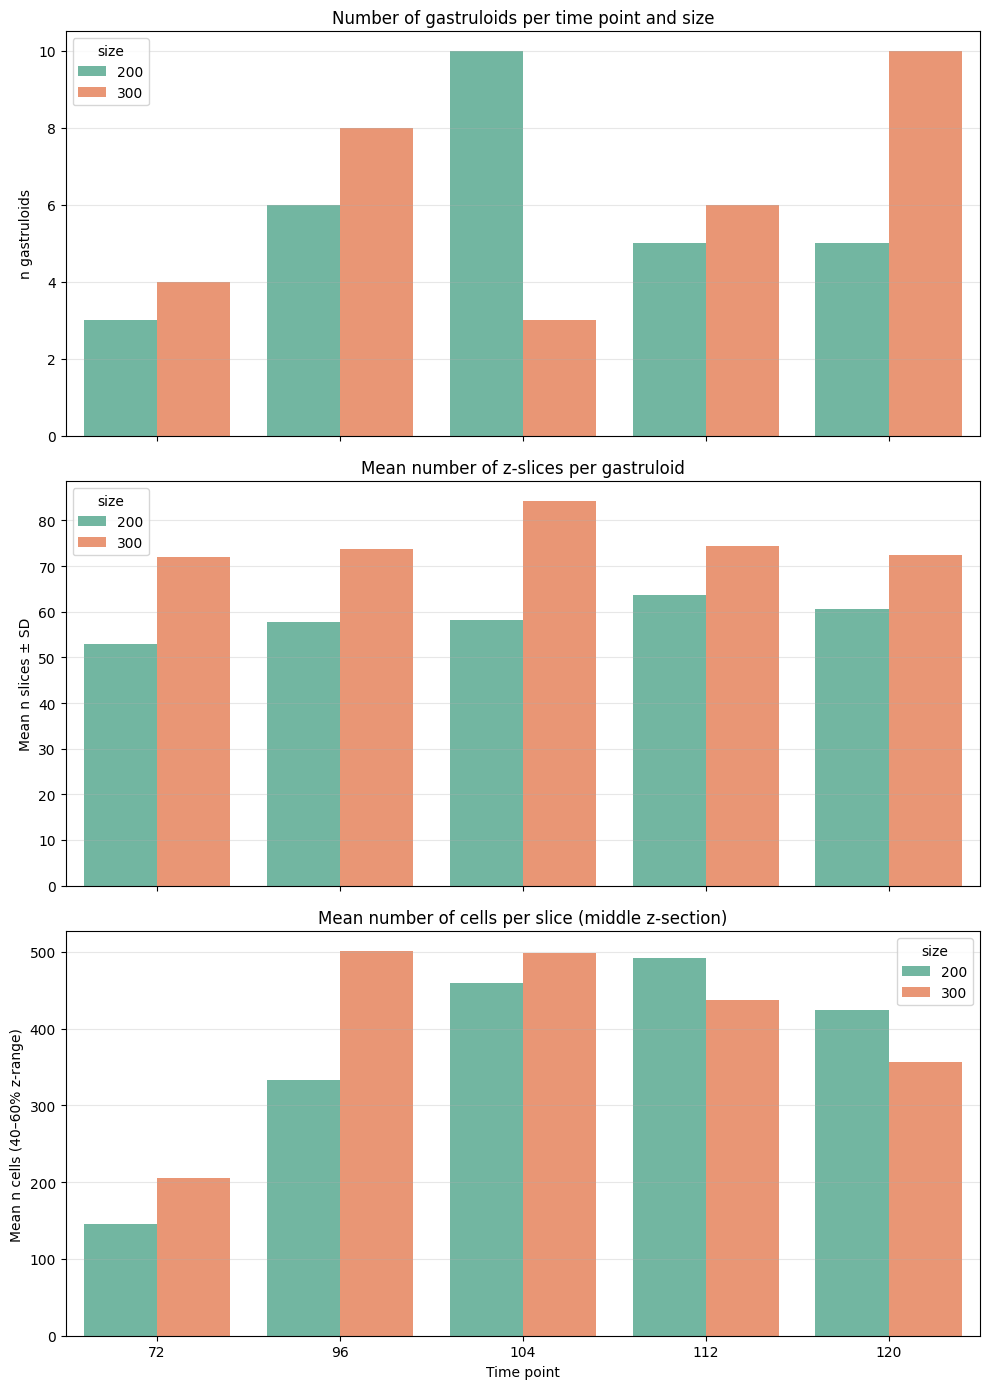

In [20]:
# ---- Step 1: number of gastruloids per time × size ----
gastruloid_counts = (
    avg_df.groupby(['time_point', 'size'])['gastruloid']
    .nunique()
    .reset_index()
    .rename(columns={'gastruloid': 'n_gastruloids'})
)

# ---- Step 2: number of z-slices per gastruloid ----
z_slices = (
    local_df.groupby(['time_point', 'size', 'gastruloid'])['slice_z']
    .nunique()
    .reset_index()
    .rename(columns={'slice_z': 'n_slices'})
)

z_slice_stats = (
    z_slices.groupby(['time_point', 'size'])['n_slices']
    .agg(['mean', 'std'])
    .reset_index()
    .rename(columns={'mean': 'mean_slices', 'std': 'std_slices'})
)

# ---- Step 3: number of cells per slice ----
cells_per_slice = (
    local_df.groupby(['time_point', 'size', 'gastruloid', 'slice_z'])
    .size()
    .reset_index(name='n_cells')
)

# ---- Step 4: restrict to middle z-section (40–60%) ----
def middle_z_mean(df):
    """Compute mean cell count in middle 40–60% z-range per gastruloid."""
    z_sorted = df.sort_values('slice_z')
    n = len(z_sorted)
    if n < 3:
        return np.nan
    start = int(0.3 * n)
    end = int(0.7 * n)
    middle_section = z_sorted.iloc[start:end]
    return middle_section['n_cells'].mean()

mid_cells = (
    cells_per_slice.groupby(['time_point', 'size', 'gastruloid'])
    .apply(middle_z_mean)
    .reset_index(name='mean_cells_mid_z')
)

cell_stats = (
    mid_cells.groupby(['time_point', 'size'])['mean_cells_mid_z']
    .agg(['mean', 'std'])
    .reset_index()
    .rename(columns={'mean': 'mean_cells_mid_z', 'std': 'std_cells_mid_z'})
)

# ---- Step 5: combine all ----
summary_df = (
    gastruloid_counts
    .merge(z_slice_stats, on=['time_point', 'size'], how='left')
    .merge(cell_stats, on=['time_point', 'size'], how='left')
)

# ---- Step 6: ensure time_point is numeric and sorted ----
summary_df["time_point"] = summary_df["time_point"].astype(int)
summary_df = summary_df.sort_values(by=["size", "time_point"])

# ---- Step 7: plot ----
fig, axes = plt.subplots(3, 1, figsize=(10, 14), sharex=True)

# define common order
time_order = sorted(summary_df["time_point"].unique())

# 1️⃣ Gastruloid counts
sns.barplot(
    data=summary_df,
    x='time_point', y='n_gastruloids', hue='size',
    order=time_order, palette='Set2', ax=axes[0]
)
axes[0].set_title("Number of gastruloids per time point and size")
axes[0].set_ylabel("n gastruloids")
axes[0].grid(alpha=0.3, axis='y')

# 2️⃣ Mean number of z-slices per gastruloid
sns.barplot(
    data=summary_df,
    x='time_point', y='mean_slices', hue='size',
    order=time_order, palette='Set2', ax=axes[1]
)
axes[1].set_title("Mean number of z-slices per gastruloid")
axes[1].set_ylabel("Mean n slices ± SD")
axes[1].grid(alpha=0.3, axis='y')

# 3️⃣ Mean number of cells per slice (middle z only)
sns.barplot(
    data=summary_df,
    x='time_point', y='mean_cells_mid_z', hue='size',
    order=time_order, palette='Set2', ax=axes[2]
)
axes[2].set_title("Mean number of cells per slice (middle z-section)")
axes[2].set_ylabel("Mean n cells (40–60% z-range)")
axes[2].grid(alpha=0.3, axis='y')

plt.xlabel("Time point")
plt.tight_layout()
plt.savefig("/Users/andreadi/Desktop/overview.png", dpi=300)
plt.show()

In [103]:
def plot_violin_with_swarm(df, y_col, title=None, palette='Set2', show_swarm=False, swarm_color='k', swarm_alpha=0.5):
    df = df.copy()
    df["time_point"] = pd.Categorical(
        df["time_point"],
        categories=sorted(df["time_point"].unique(), key=int),
        ordered=True
    )

    plt.figure(figsize=(12, 6))
    sns.violinplot(
        data=df,
        x='time_point',
        y=y_col,
        hue='size',
        split=True,
        palette=palette, inner="quartile",
    )

    if show_swarm:
        sizes = df["size"].unique()
        for sz in sizes:
            subset = df[df["size"] == sz]
            sns.swarmplot(
                data=subset,
                x='time_point',
                y=y_col,
                color=swarm_color,
                alpha=swarm_alpha,
                dodge=True
            )

    plt.xlabel("Time point")
    plt.ylabel(y_col.replace('_', ' ').capitalize())
    if title is not None:
        plt.title(title)
    plt.grid(alpha=0.3, axis='y')
    plt.legend(title='Size')
    plt.savefig(os.path.join(comp_fig_dir, f'{title}.{comp_fig_type}'), dpi=comp_fig_dpi)
    plt.show()

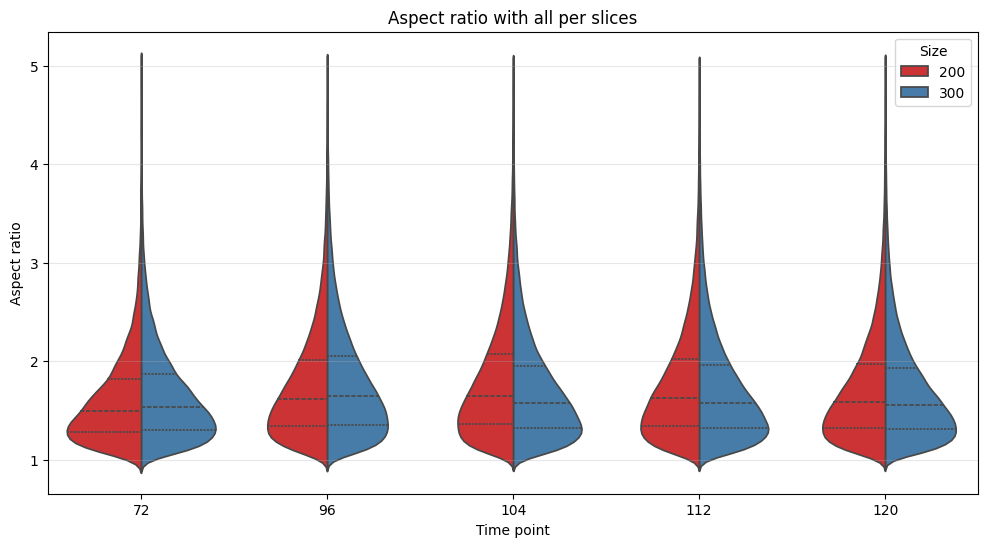

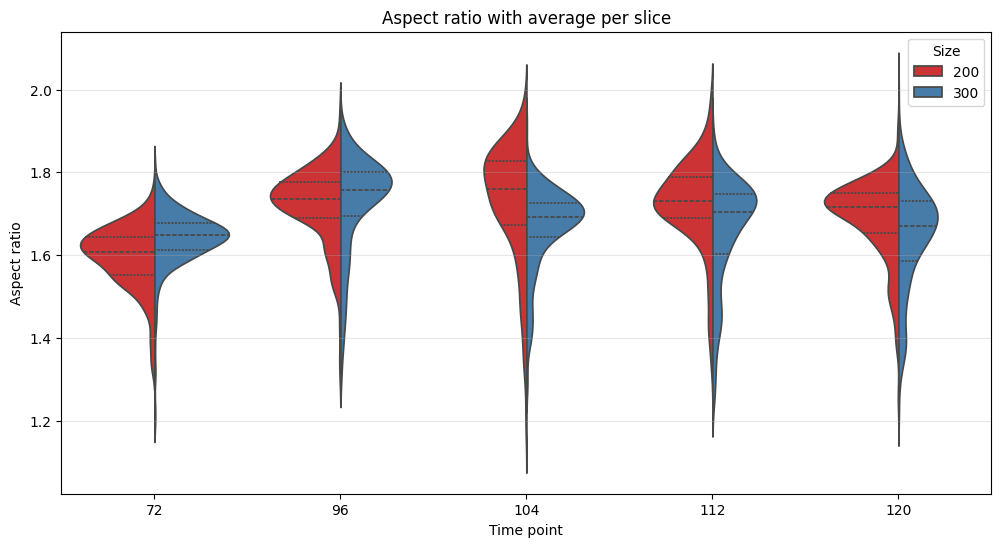

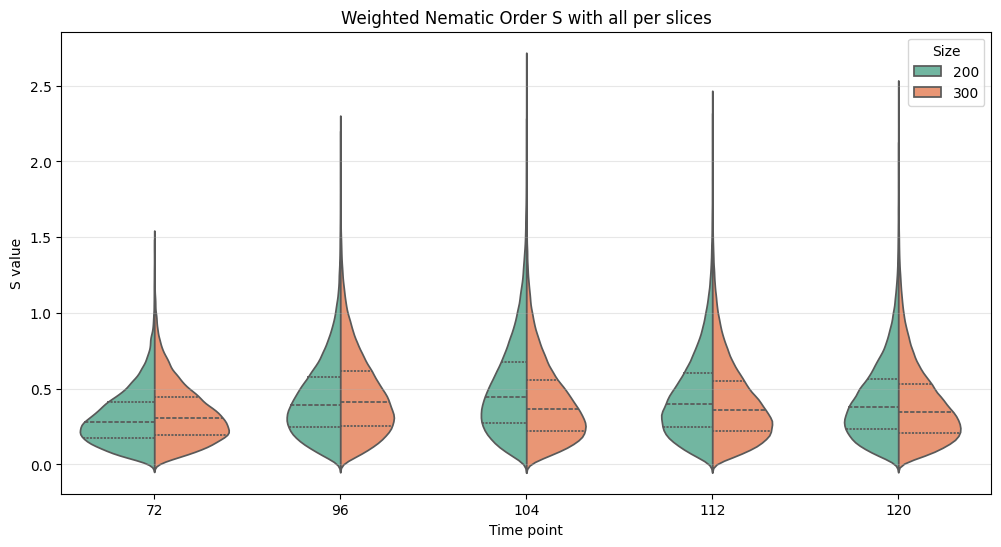

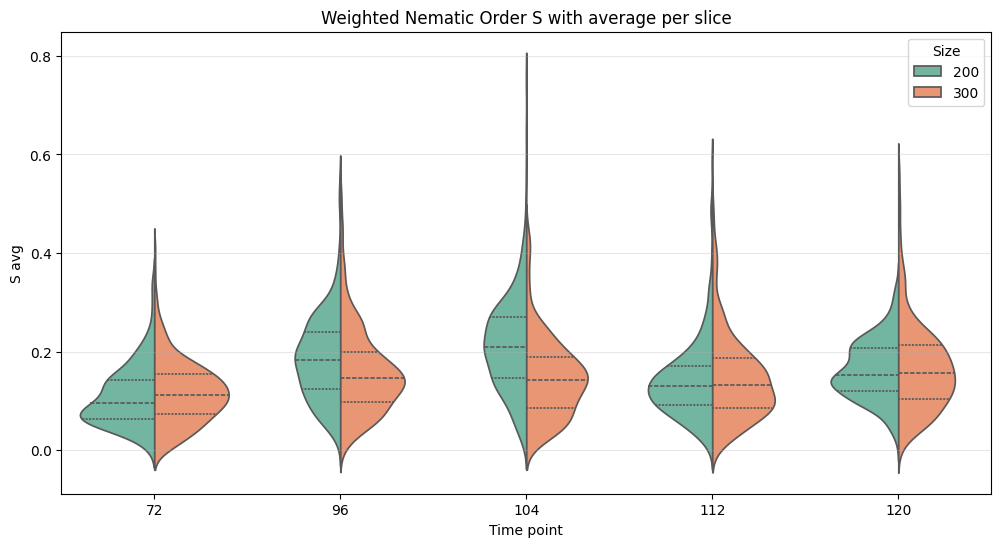

In [105]:
plot_violin_with_swarm(local_df, 'aspect_ratio', title="Aspect ratio with all per slices", palette='Set1')
plot_violin_with_swarm(avg_df, 'aspect_ratio', title="Aspect ratio with average per slice", palette='Set1')
plot_violin_with_swarm(local_df, 'S_value', title="Weighted Nematic Order S with all per slices", palette='Set2')
plot_violin_with_swarm(avg_df, 'S_avg', title="Weighted Nematic Order S with average per slice", palette='Set2')

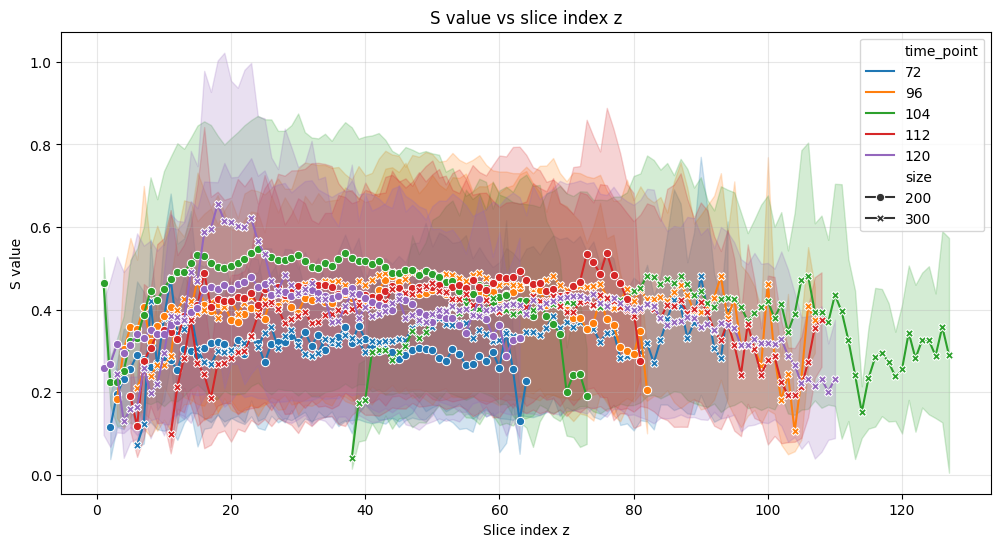

In [37]:
# Choose measurement
y_col = "S_value"
# y_col = "aspect_ratio"

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=local_df,
    x="slice_z",
    y=y_col,
    hue="time_point",
    style="size",
    ci="sd",  # shaded area = standard deviation
    markers=True,
    dashes=False
)
plt.xlabel("Slice index z")
plt.ylabel(y_col.replace('_', ' ').capitalize())
plt.title(f"{y_col.replace('_', ' ').capitalize()} vs slice index z")
plt.grid(alpha=0.3)
plt.savefig(os.path.join(comp_fig_dir, f'{y_col}.{comp_fig_type}'), dpi=comp_fig_dpi)
plt.show()

In [38]:
# Average S across all gastruloids, all time points
def plot_aligned_z(
        df,
        y_col,
        time_point=None,
        size=None,
        group_cols=None,
        hue_col="time_point",
        style_col="size",
        mode="line",  # "line" or "scatter"
        separate_gastruloids=False,
        estimator="mean",
        ci="sd",
        markers=True,
        dashes=False,
        alpha=0.7,
        s=40,
        figsize=(12, 6)
):
    if group_cols is None:
        group_cols = ["time_point", "size", "gastruloid"]

    df_copy = df.copy()

    # ---- Apply filters ----
    if time_point is not None:
        df_copy = df_copy[df_copy["time_point"] == str(time_point)]
    if size is not None:
        df_copy = df_copy[df_copy["size"] == str(size)]

    # ---- Center z by gastruloid ----
    df_copy["z_centered"] = df_copy.groupby(group_cols)["slice_z"] \
        .transform(lambda x: x - np.median(x))

    # ---- Plot setup ----
    plt.figure(figsize=figsize)

    if separate_gastruloids:
        g = sns.FacetGrid(
            df_copy,
            col="gastruloid",
            hue=hue_col,
            col_wrap=4,
            sharex=True,
            sharey=True,
            height=3
        )
        if mode == "line":
            # 🔧 Removed `style` to prevent label duplication error
            g.map_dataframe(
                sns.lineplot,
                x="z_centered", y=y_col,
                estimator=estimator,
                ci=ci,
                markers=markers,
                dashes=dashes
            )
        else:
            g.map_dataframe(
                sns.scatterplot,
                x="z_centered", y=y_col,
                alpha=alpha,
                s=s
            )

        g.add_legend()
        g.set_titles(col_template="{col_name}")
        g.set_axis_labels("Slice z (centered)", y_col)
        plt.subplots_adjust(top=0.9)
        suptitle = f"Aligned {y_col} vs z — separated by gastruloid"
        g.fig.suptitle(suptitle)
        plt.savefig(os.path.join(comp_fig_dir, f'{suptitle}_time-{time_point}_size={size}.{comp_fig_type}'),
                    dpi=comp_fig_dpi)
        plt.show()
    else:
        if mode == "line":
            sns.lineplot(
                data=df_copy,
                x="z_centered",
                y=y_col,
                hue=hue_col,
                style=style_col,
                estimator=estimator,
                ci=ci,
                markers=markers,
                dashes=dashes
            )
        elif mode == "scatter":
            sns.scatterplot(
                data=df_copy,
                x="z_centered",
                y=y_col,
                hue=hue_col,
                style=style_col,
                alpha=alpha,
                s=s
            )

        plt.xlabel("Slice z (centered on median per gastruloid)")
        plt.ylabel(y_col)
        title = f"Aligned {y_col} vs z"
        if time_point:
            title += f" — time {time_point}"
        if size:
            title += f", size {size}"
        plt.title(title)
        plt.grid(alpha=0.3)
        plt.savefig(os.path.join(comp_fig_dir, f'{title}_time-{time_point}_size={size}.{comp_fig_type}'),
                    dpi=comp_fig_dpi)
        plt.show()


In [125]:
local_df["z_centered"]

0          0.0
1          0.0
2          0.0
3          0.0
4          0.0
          ... 
1044947    0.0
1044948    0.0
1044949    0.0
1044950    0.0
1044951    0.0
Name: z_centered, Length: 1044952, dtype: float64

In [127]:
local_df["z_centered"] = (
    local_df.groupby(["time_point", "size", "gastruloid"])["slice_z"]
    .transform(lambda x: x - np.median(x))
)

<Axes: title={'center': 'Time point = 120h and Size = 200'}, xlabel='aspect_ratio', ylabel='z_centered'>

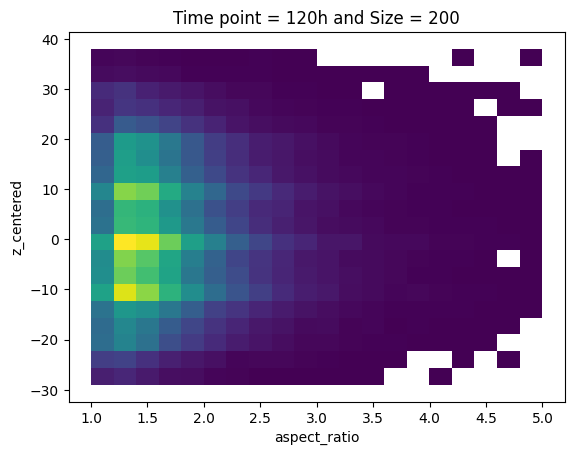

In [135]:
t_sel, size_sel = "120", "200"
plt.title(f"Time point = {t_sel}h and Size = {size_sel}")
sns.histplot(data=local_df[(local_df["time_point"] == t_sel) & (local_df["size"] == size_sel)], y="z_centered",
             x="aspect_ratio", bins=20, cmap="viridis")

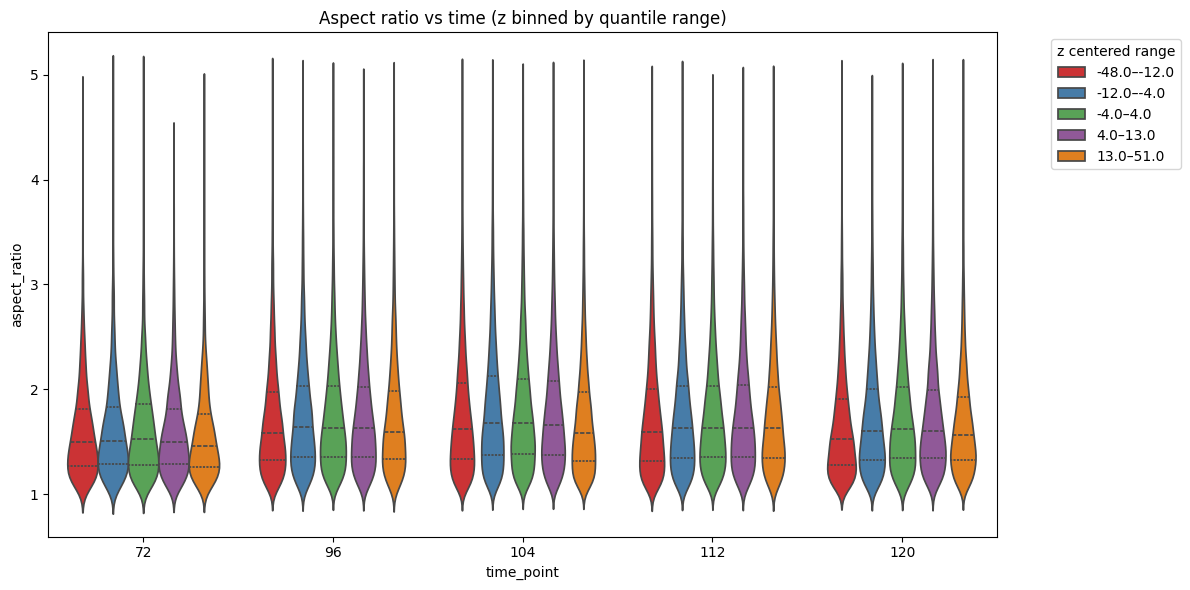

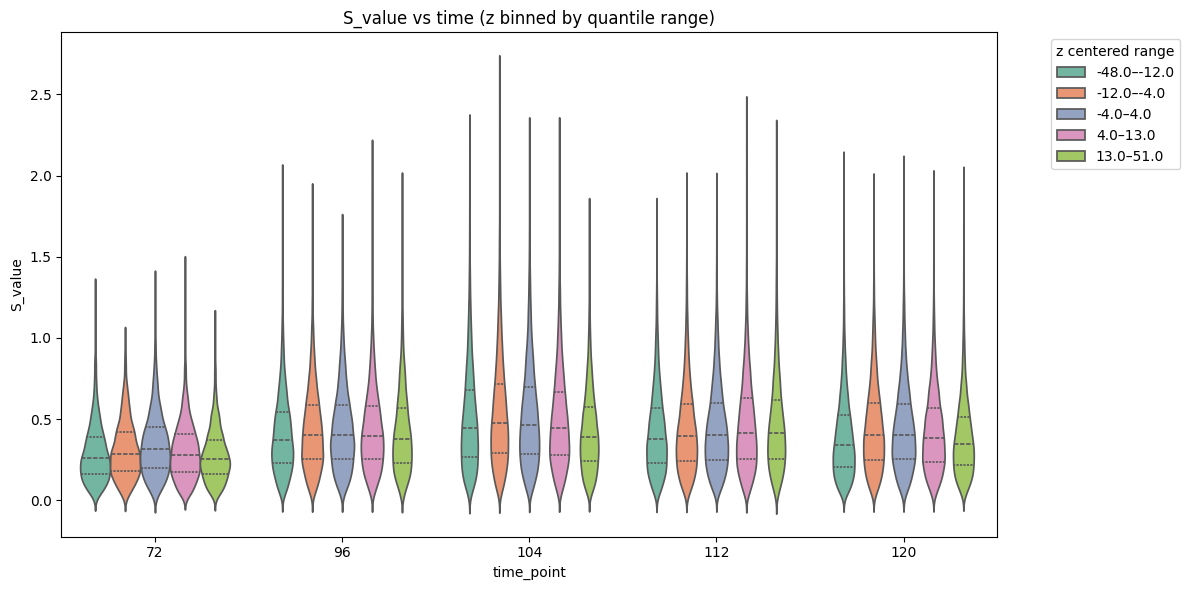

In [153]:
# Create quantile bins and capture bin edges
z_bins, bin_edges = pd.qcut(local_df["z_centered"], q=5, retbins=True, duplicates="drop")

# Format bin labels with ranges (rounded for clarity)
bin_labels = [
    f"{bin_edges[i]:.1f}–{bin_edges[i + 1]:.1f}" for i in range(len(bin_edges) - 1)
]

# Apply categorical labels
local_df["z_group"] = pd.qcut(local_df["z_centered"], q=5, labels=bin_labels)

# Plot
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=local_df[local_df["size"] == "200"],
    x="time_point",
    y="aspect_ratio",
    hue="z_group",
    palette="Set1",
    inner="quartile"
)
plt.legend(title="z centered range", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("Aspect ratio vs time (z binned by quantile range)")
plt.tight_layout()
plt.show()

# Create quantile bins and capture bin edges
z_bins, bin_edges = pd.qcut(local_df["z_centered"], q=5, retbins=True, duplicates="drop")

# Format bin labels with ranges (rounded for clarity)
bin_labels = [
    f"{bin_edges[i]:.1f}–{bin_edges[i + 1]:.1f}" for i in range(len(bin_edges) - 1)
]

# Apply categorical labels
local_df["z_group"] = pd.qcut(local_df["z_centered"], q=5, labels=bin_labels)

# Plot
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=local_df[local_df["size"] == "200"],
    x="time_point",
    y="S_value",
    hue="z_group",
    palette="Set2",
    inner="quartile"
)
plt.legend(title="z centered range", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("S_value vs time (z binned by quantile range)")
plt.tight_layout()
plt.show()

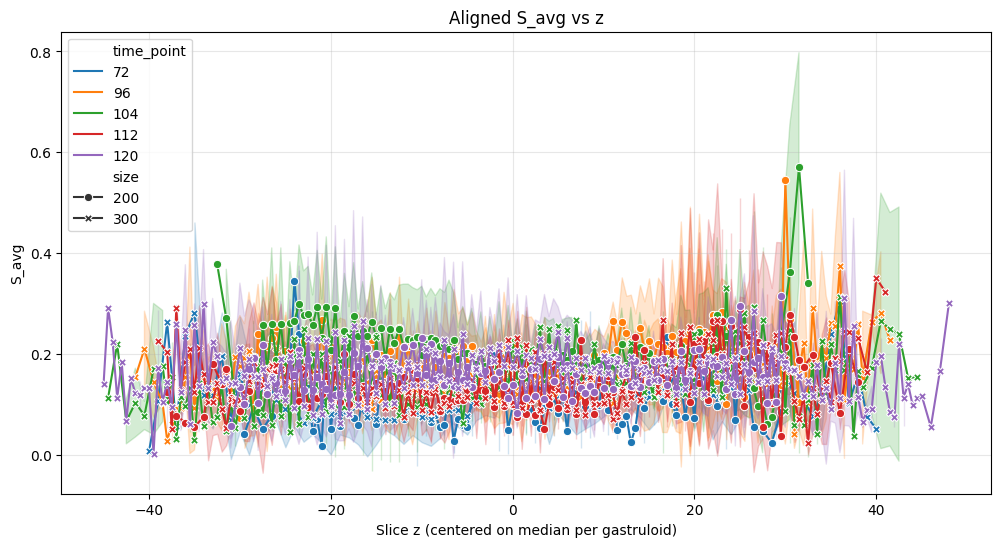

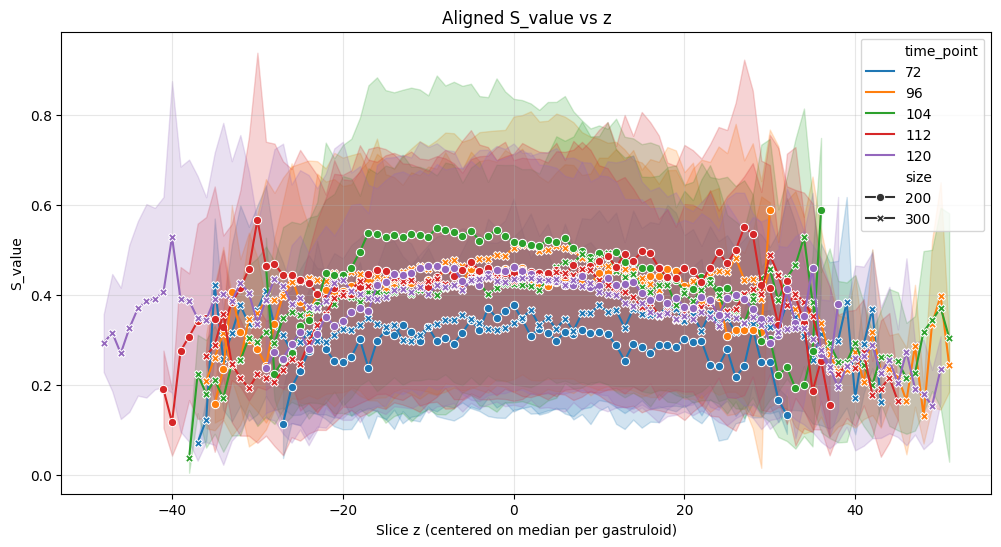

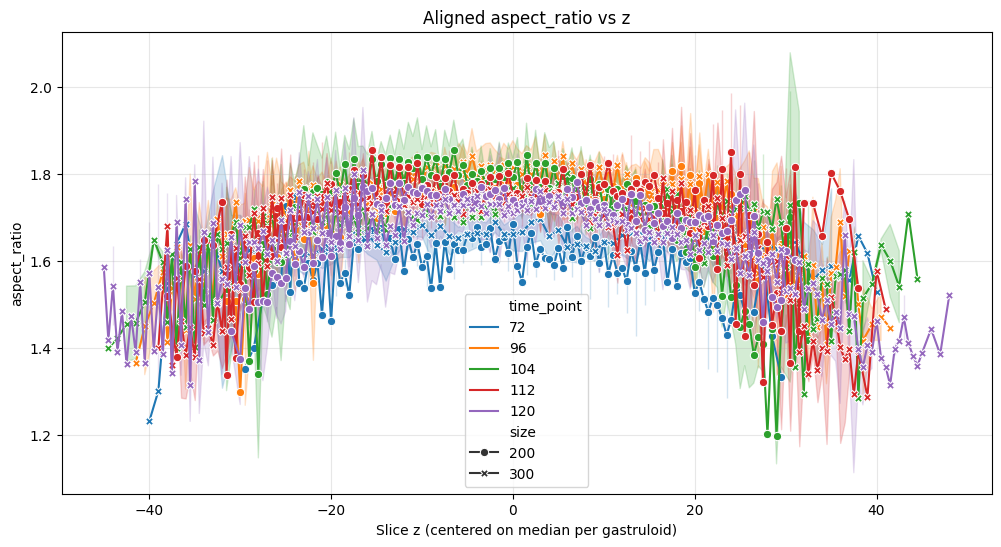

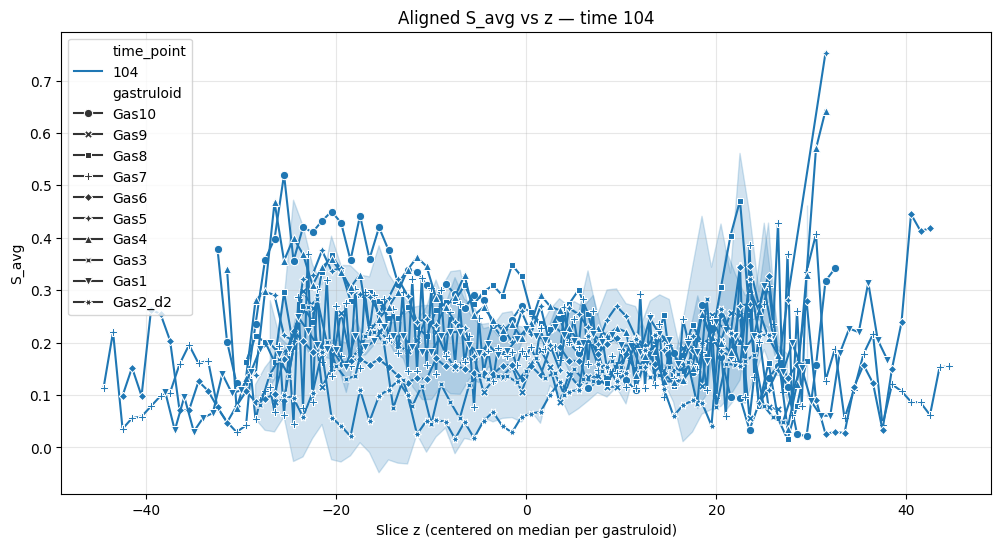

In [39]:
# Average S across all gastruloids, all time points
plot_aligned_z(avg_df, y_col="S_avg")

# Local weighted S per cell
plot_aligned_z(local_df, y_col="S_value")

# Aspect ratio per slice, all time points
plot_aligned_z(avg_df, y_col="aspect_ratio")
plot_aligned_z(avg_df, y_col="S_avg", time_point="104", style_col="gastruloid")

<Figure size 1200x600 with 0 Axes>

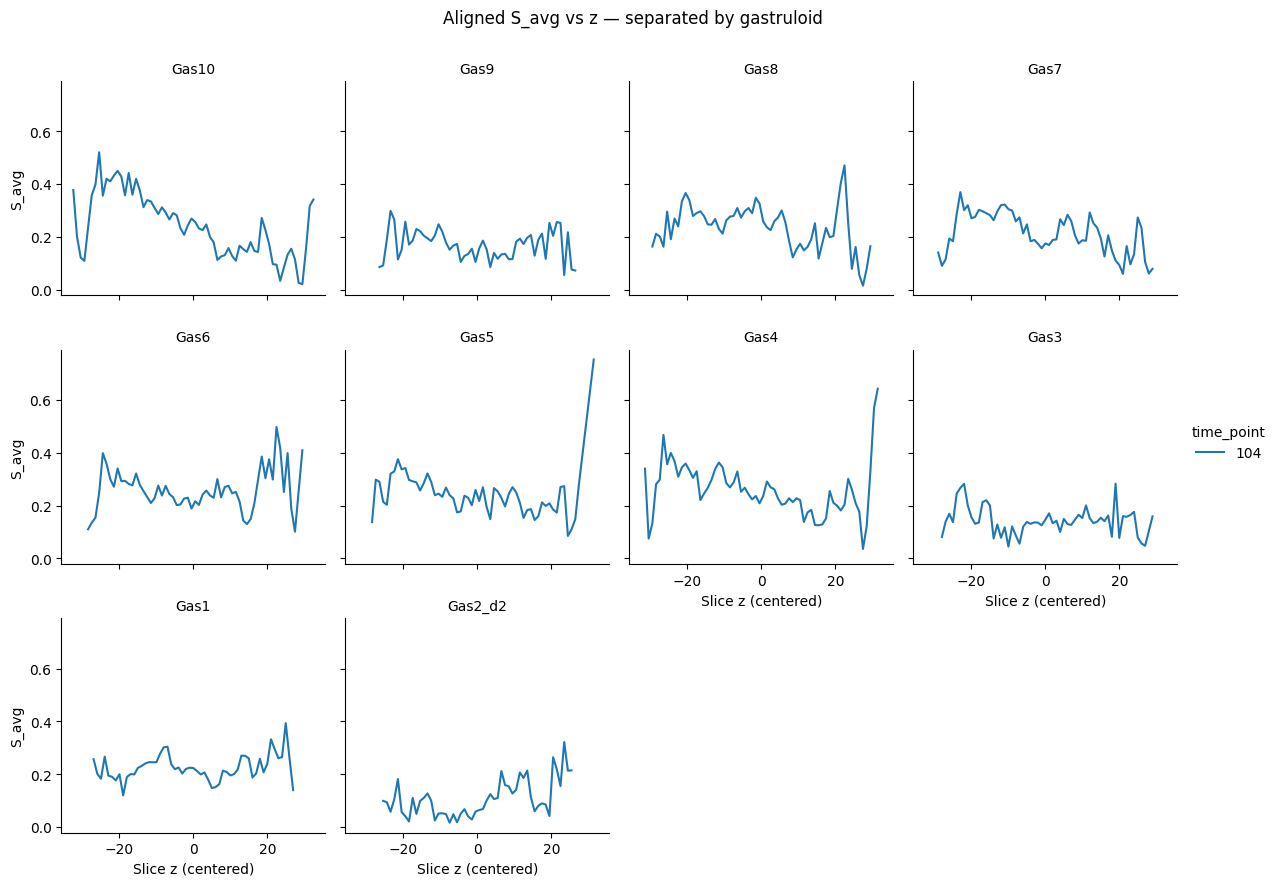

In [40]:

plot_aligned_z(avg_df, y_col="S_avg", time_point="104", style_col="gastruloid", separate_gastruloids=True, size=200)

<Figure size 1200x600 with 0 Axes>

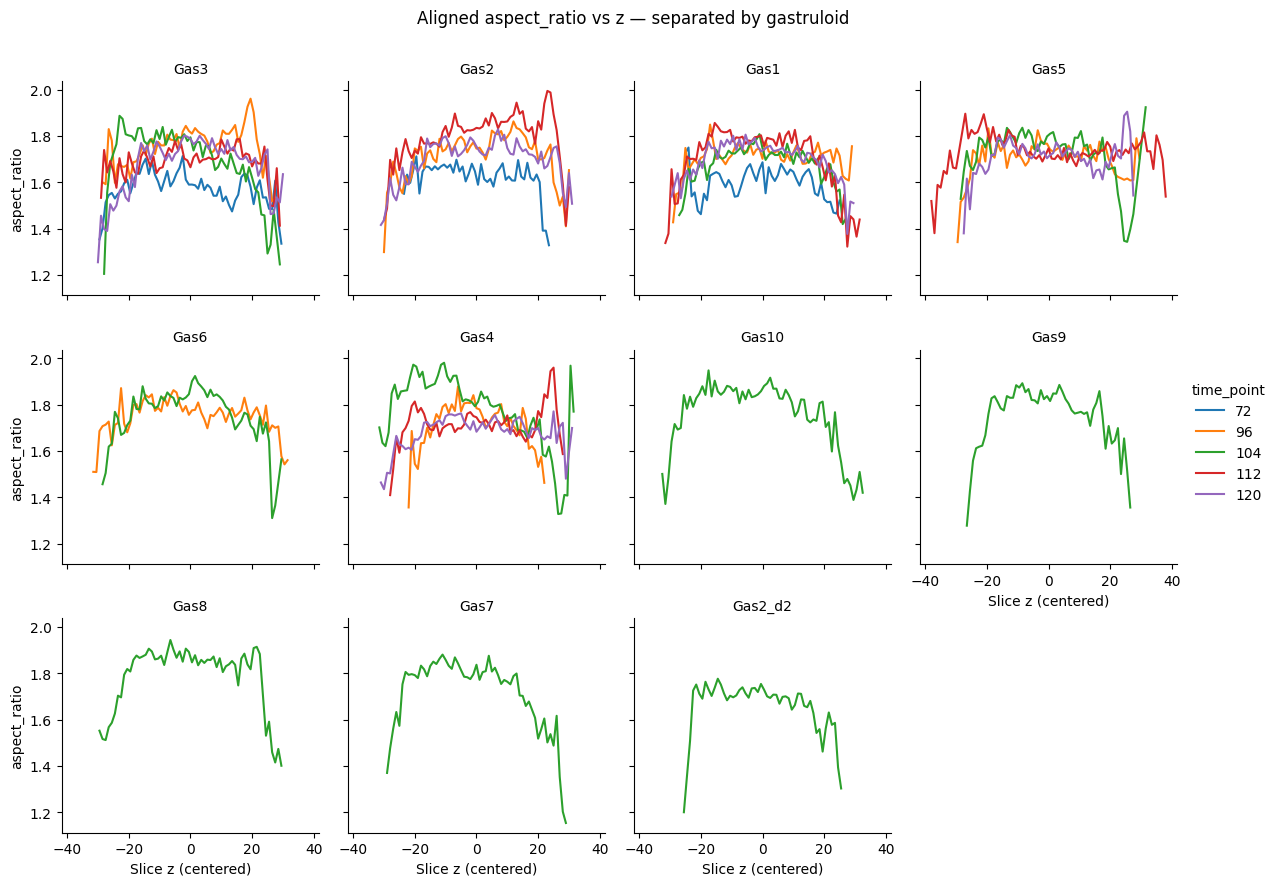

In [41]:
plot_aligned_z(avg_df, y_col="aspect_ratio", size="200", mode="line", separate_gastruloids=True)

<Axes: xlabel='aspect_ratio', ylabel='S_value'>

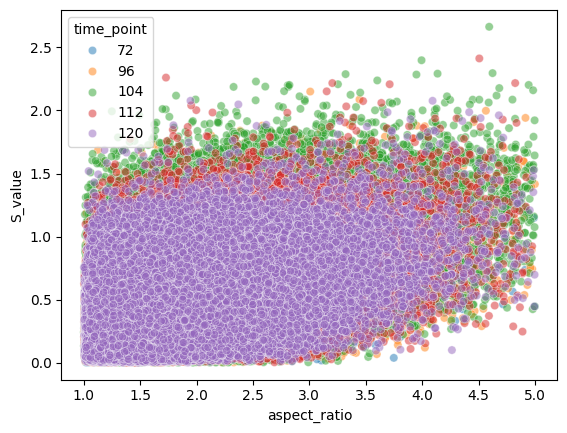

In [159]:
sns.scatterplot(local_df[local_df["size"] == "200"], x="aspect_ratio", y="S_value", hue="time_point", alpha=0.5)

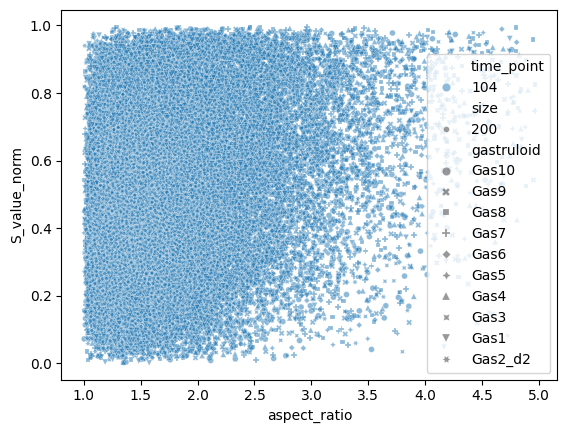

<Axes: xlabel='aspect_ratio', ylabel='S_value_norm'>

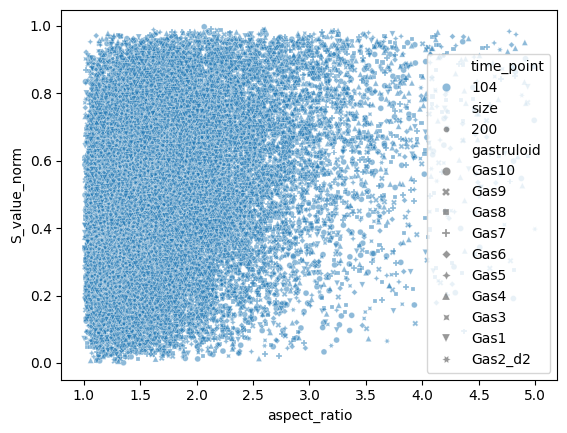

In [189]:
sns.scatterplot(
    local_df[(local_df["time_point"] == "104") & (local_df["size"] == "200") & (local_df["z_group"] == "-4.0–4.0")],
    x="aspect_ratio", y="S_value_norm", hue="time_point", size="size", style="gastruloid", alpha=0.5)
plt.show()
sns.scatterplot(
    local_df[(local_df["time_point"] == "104") & (local_df["size"] == "200") & (local_df["z_group"] == "-48.0–-12.0")],
    x="aspect_ratio", y="S_value_norm", hue="time_point", size="size", style="gastruloid", alpha=0.5)

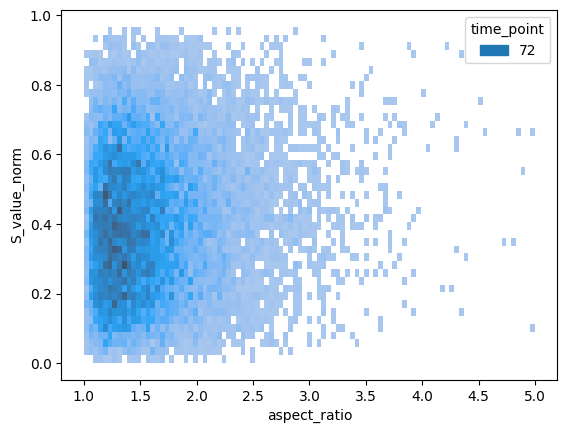

<Axes: xlabel='aspect_ratio', ylabel='S_value_norm'>

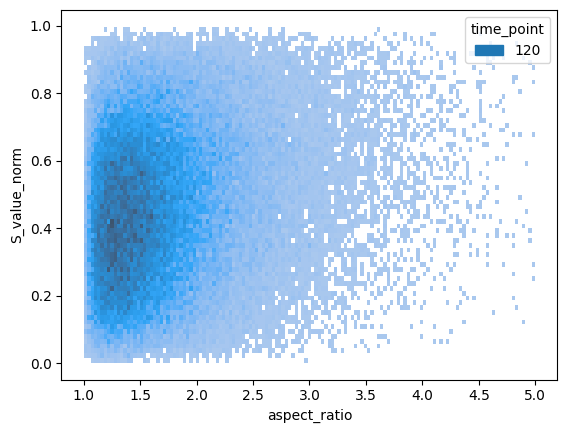

In [208]:
sns.histplot(
    local_df[(local_df["time_point"] == "72") & (local_df["size"] == "200")],
    x="aspect_ratio", y="S_value_norm", hue="time_point")
plt.show()
sns.histplot(
    local_df[(local_df["time_point"] == "120") & (local_df["size"] == "200")],
    x="aspect_ratio", y="S_value_norm", hue="time_point")

<Axes: xlabel='aspect_ratio', ylabel='S_value'>

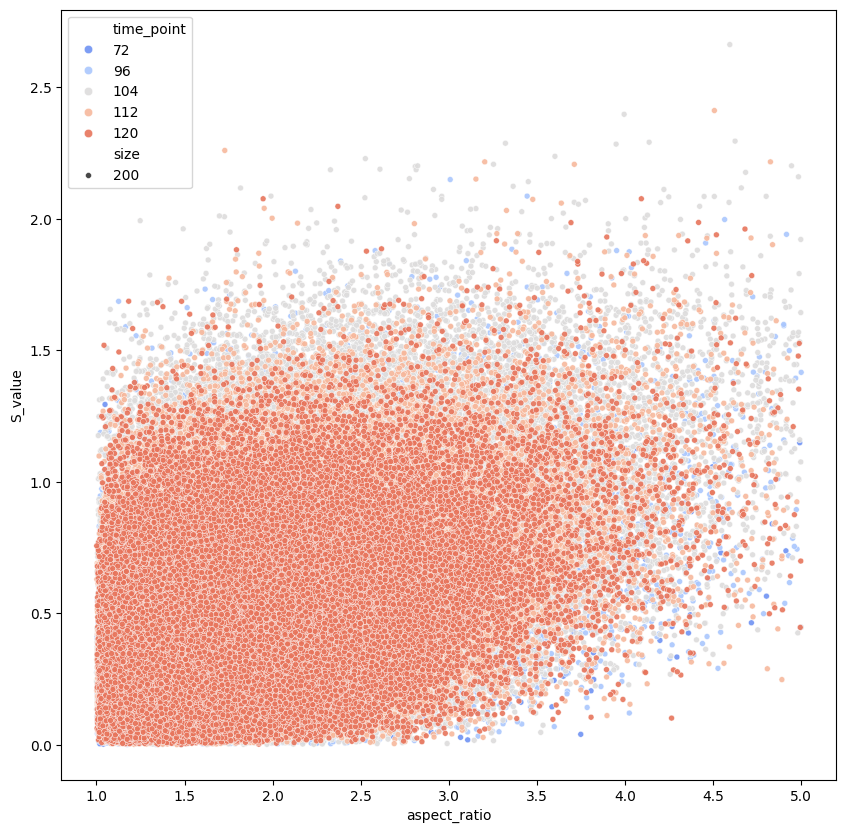

In [178]:
plt.figure(figsize=(10, 10))
sns.scatterplot(local_df[(local_df["size"] == "200")], x="aspect_ratio", y="S_value", hue="time_point", size="size",
                alpha=0.9, palette="coolwarm")

/var/folders/tr/c3y2bbmj497_wxvc_66mzyqr0000gn/T/ipykernel_75005/2917613721.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(local_df, x="aspect_ratio", y="S_value", alpha=0.9,


Text(0.5, 1.0, 'Weighted nematic order $S$ using 6 nearest-neighbours vs. aspect ratio')

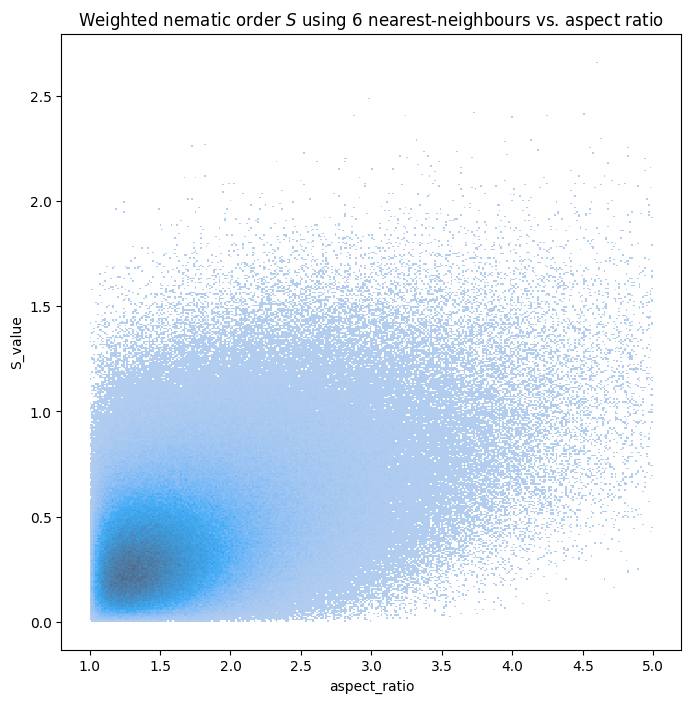

In [13]:
plt.figure(figsize=(8, 8))
sns.histplot(local_df, x="aspect_ratio", y="S_value", alpha=0.9,
             palette="coolwarm")
plt.title("Weighted nematic order $S$ using 6 nearest-neighbours vs. aspect ratio")